In [1]:
import torch
import matplotlib.pyplot as plt

data = torch.load("datasets/PrimaryOnlyUniform_Epos_WITHCUBELETID.pt", map_location="cpu") #PrimaryOnlyUniform_Epos All_Epos


print(data.keys())
print(data["target_name"])

X = data["samples"]       # shape: (N, timesteps, sensors)
Y = data["targets"]       # shape: (N, 4)
C = data["cubelets"]      # shape: (N,)

for i in range(len(X)):
    for j in range(len(X[i])):
        if X[i][j].sum() != 0:
            print(f"Event {i} at timestep {j} has data:")
            print(X[i][j]) # all sensors for event i at timestep j
            break
        break
    break


print(X[0][0].sum())
print(Y[0]) # target values for event 0

E = Y[:, 0].unsqueeze(1)       # (N_events, 1)
print('Energies per event (MeV):', E.squeeze())
Nphot = X.sum(dim=(1)) # total photons per event in each sensors
print('Nphot per event:', Nphot)
print(E.shape, Nphot.shape)



# Count elements above 100 in event 0
count_over_100 = (X > 100).sum().item()
print("Number of elements > 100 in event 0:", count_over_100, "out of", X.numel())

# Print the max value
print("Max photon count in event 0:", X[0].max().item())

/tmp/ipykernel_775400/2419945193.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("datasets/PrimaryOnlyUniform_Epos_WITHCUBELETID.pt", map_location="cpu

dict_keys(['samples', 'cubelets', 'targets', 'target_name'])
['energy', 'centroid']
tensor(0.)
tensor([3.1648, 0.8779, 2.4434, 8.3639])
Energies per event (MeV): tensor([3.1648, 3.8624, 3.6587,  ..., 4.3107, 3.9927, 4.3187])
Nphot per event: tensor([[   593.,    586.,    562.,  ...,  12918.,  10373.,   8244.],
        [  1365.,   3149.,   8868.,  ...,  27681.,  18574.,  13286.],
        [  2137.,   2304.,   2398.,  ...,  13982.,  10592.,   8286.],
        ...,
        [ 12083.,  14183.,  16530.,  ...,  77325.,  80956.,  75787.],
        [ 11670.,  11937.,  11953.,  ...,  38132.,  42223.,  26328.],
        [  3109.,   3332.,   3553.,  ..., 177192., 134395., 100092.]])
torch.Size([14942, 1]) torch.Size([14942, 100])
Number of elements > 100 in event 0: 7872822 out of 149420000
Max photon count in event 0: 17457.0


In [2]:
print(X[0])
print(X[0].shape) # (timesteps, sensors)
print(X.shape) # (N_events, timesteps, sensors)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
torch.Size([100, 100])
torch.Size([14942, 100, 100])


In [3]:
import numpy as np
c = np.array([])
for i in C.detach().cpu().numpy():
    c = np.append(c, i)
print(np.sort(np.unique(c)))

[ 45.  54.  55.  56.  65.  66. 145. 146. 154. 155. 156. 165. 245. 246.
 254. 255. 256. 265. 345. 346. 354. 355. 356. 365. 366. 445. 446. 454.
 455. 456. 465. 545. 546. 554. 555. 556. 565. 645. 646. 654. 655. 656.
 665. 744. 745. 746. 754. 755. 756. 765. 845. 854. 855. 856. 865. 866.
 945. 954. 955. 956. 965. 966.]


/tmp/ipykernel_775400/3457645068.py:102: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


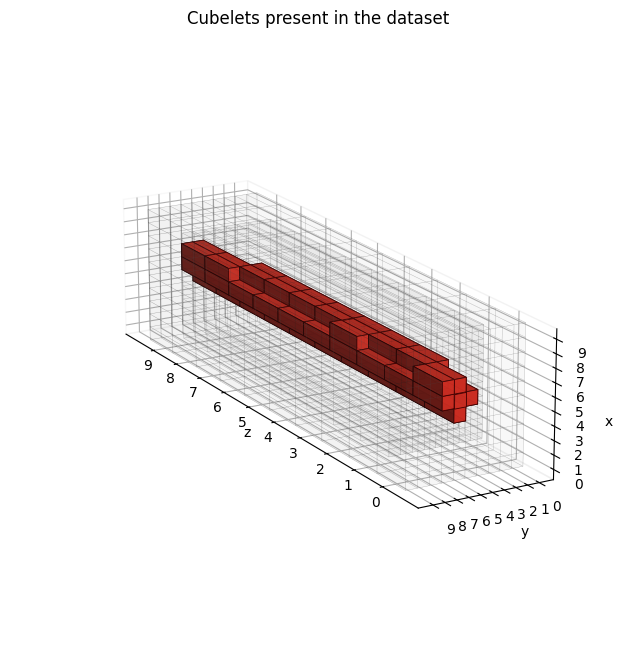

In [4]:
import numpy as np
import matplotlib.pyplot as plt

selected_zyx = np.array(np.unique(c), dtype=int)

# logical detector dimensions
nx = ny = nz = 10

# physical voxel dimensions:
# original coordinates are (x, y, z) = (1, 1, 4) in relative units
# but we plot with z horizontal, so plotted axes are (z, y, x)
dx, dy, dz = 1.0, 1.0, 4.0
plot_nx, plot_ny, plot_nz = nz, ny, nx
plot_dx, plot_dy, plot_dz = dz, dy, dx

xp = np.arange(plot_nx + 1) * plot_dx
yp = np.arange(plot_ny + 1) * plot_dy
zp = np.arange(plot_nz + 1) * plot_dz
X, Y, Z = np.meshgrid(xp, yp, zp, indexing="ij")

# ----------------------------
# 1) faint outer shell only
# ----------------------------
shell = np.zeros((plot_nx, plot_ny, plot_nz), dtype=bool)
for iz in range(plot_nx):
    for iy in range(plot_ny):
        for ix in range(plot_nz):
            if (
                iz == 0 or iz == plot_nx - 1 or
                iy == 0 or iy == plot_ny - 1 or
                ix == 0 or ix == plot_nz - 1
            ):
                shell[iz, iy, ix] = True

shell_facecolors = np.zeros((plot_nx, plot_ny, plot_nz, 4), dtype=float)
shell_edgecolors = np.zeros((plot_nx, plot_ny, plot_nz, 4), dtype=float)

shell_facecolors[shell] = [0.75, 0.75, 0.75, 0.035]
shell_edgecolors[shell] = [0.35, 0.35, 0.35, 0.22]

# ----------------------------
# 2) selected cubes only
# ----------------------------
selected = np.zeros((plot_nx, plot_ny, plot_nz), dtype=bool)
sel_facecolors = np.zeros((plot_nx, plot_ny, plot_nz, 4), dtype=float)
sel_edgecolors = np.zeros((plot_nx, plot_ny, plot_nz, 4), dtype=float)

for n in selected_zyx:
    zc = n // 100
    yc = (n // 10) % 10
    xc = n % 10

    # plotting axes are (z, y, x)
    selected[zc, yc, xc] = True
    sel_facecolors[zc, yc, xc] = [0.90, 0.20, 0.15, 0.95]
    sel_edgecolors[zc, yc, xc] = [0.30, 0.00, 0.00, 1.00]

# ----------------------------
# plot
# ----------------------------
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# draw shell first
ax.voxels(
    X, Y, Z,
    shell,
    facecolors=shell_facecolors,
    edgecolors=shell_edgecolors,
    linewidth=0.25
)

# draw selected cubes on top
ax.voxels(
    X, Y, Z,
    selected,
    facecolors=sel_facecolors,
    edgecolors=sel_edgecolors,
    linewidth=0.6
)

ax.set_xlabel("z")
ax.set_ylabel("y")
ax.set_zlabel("x")

ax.set_xticks(np.arange(nz) * dz + dz / 2)
ax.set_yticks(np.arange(ny) * dy + dy / 2)
ax.set_zticks(np.arange(nx) * dx + dx / 2)

ax.set_xticklabels(range(nz))
ax.set_yticklabels(range(ny))
ax.set_zticklabels(range(nx))

ax.set_box_aspect((nz * dz, ny * dy, nx * dx))

ax.view_init(elev=18, azim=150)

for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.fill = False

plt.title("Cubelets present in the dataset")
plt.tight_layout()
plt.show()